##### This is for generating WordClouds based on the NGRAMS API and using Z-scores

In [1]:
#pip install stopwordsiso

In [2]:
#importing libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time
from stopwordsiso import stopwords
import re

In [3]:
#loading the data

df = pd.read_csv('evaluation_results3.csv')
df.head(5)

,ID,Data Provider,Project Name,Consumer Team,Consumer Name,Consumer Description,Variation Type,Variation Value,Purpose,Realistic?,Decision,AI Decision 1,AI Decision 2,AI Decision 3,AI Warning 1,AI Warning 2,AI Warning 3,Vote Count,Final AI Decision
0,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,NaN,Original Request,"To improve our risk assessment process, we aim...","Yes, this is a realistic access request for a ...",Accept,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
1,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + very hasty (typos, shorthand, missing...",hey need access to old claims data asap gotta ...,NaN,NaN,Reject,Reject,Reject,"{'title': 'Default policies', 'policyKey': 'gl...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'default', 'title': 'Default pol...",0-3,Reject
2,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"intern + neutral (standard professional, no pa...",I'm looking to access historical claims data t...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
3,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,intern + very formal (precise legal-style lang...,I hereby formally request access to the histor...,NaN,NaN,Accept,Accept,Accept,NaN,NaN,NaN,3-0,Accept
4,8392a6d9159cc8a43f7794b73694e375edddcaecc8afb2...,Benefit,Claims Risk Pattern Analysis,underwriting,Risk Insight Tool,A platform designed to offer in-depth risk ins...,combined,"junior analyst + very hasty (typos, shorthand,...",hey can I get access to the old claims data? n...,NaN,NaN,Reject,Reject,Reject,"{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...","{'policyKey': 'Default policies', 'title': 'Da...",0-3,Reject


In [4]:
#extracting columns for the seniority and the hastiness dimension.

def extracting_seniority(text):
    text = str(text).lower()

    if "intern" in text:
        return "Intern"
    elif "junior analyst" in text:
        return "Junior Analyst"
    elif "senior manager" in text:
        return "Senior Manager"
    elif "executive/ceo" in text:
        return "Executive/CEO"
    elif "original request" in text:
        return "Original"
    return None


def extracting_hastiness(text):
    text = str(text).lower()

    if "very hasty" in text:
        return "Very Hasty"
    elif "neutral" in text:
        return "Neutral"
    elif "very formal" in text:
        return "Very Formal"
    elif "original request" in text:
        return "Original"
    return None

df['Seniority'] = df['Variation Value'].apply(extracting_seniority)
df['Hastiness'] = df['Variation Value'].apply(extracting_hastiness)



seniority_category=["Intern", "Junior Analyst", "Senior Manager", "Executive/CEO", "Original"]
hastiness_category=["Very Hasty", "Neutral", "Very Formal", "Original"]

df["Seniority"] = pd.Categorical(df["Seniority"],categories = seniority_category, ordered=True)
df["Hastiness"] = pd.Categorical(df["Hastiness"],categories = hastiness_category, ordered=True)



In [5]:
#cleaning the text and tokenising it (removing punctuation etc.)

#adding the stopwords for the most common english words
english_stopwords = stopwords("en")

#common words in every request that aren't useful for distinguishing style (mostly used for data reuquests)
custom_stopwords = {
    "data",
    "access",
    "request",
    "requests",
    "customer",
    "consumer",
    "project",
    "team",
    "dataset",
    "datasets",
    "table",
    "tables",
    "record",
    "records",
    "database",
    "information"
}
all_stopwords = english_stopwords.union(custom_stopwords) #combining the stopwords and the custom stopwords

def tokenise(text):
    if pd.isna(text):
        return []

    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()

    #remove stop words
    words = [word for word in words if word not in all_stopwords]

    return words

#applying the tokenis into the purpose column
df["Tokens"] = (df["Purpose"].apply(tokenise))

#checking if it works
df[['Purpose', 'Tokens']].head(5)

,Purpose,Tokens
0,"To improve our risk assessment process, we aim...","[improve, risk, assessment, process, aim, anal..."
1,hey need access to old claims data asap gotta ...,"[hey, claims, asap, gotta, check, risk, patter..."
2,I'm looking to access historical claims data t...,"[historical, claims, improve, risk, assessment..."
3,I hereby formally request access to the histor...,"[formally, historical, claims, conduct, analys..."
4,hey can I get access to the old claims data? n...,"[hey, claims, check, risk, trends, dif, action..."


In [6]:
print(df["Tokens"].iloc[1])

['hey', 'claims', 'asap', 'gotta', 'check', 'risk', 'patterns', 'tied', 'diff', 'actions', 'wanna', 'beneficiaries', 'info', 'risk', 'profiles', 'types', 'thisll', 'tweak', 'underwriting', 'predict', 'premiums', 'upcoming', 'policies', 'goal', 'policies', 'match', 'real', 'risk', 'helps', 'company', 'financial', 'guesses', 'customers', 'fair', 'insurance', 'prices', 'thx']


In [7]:
#calculating the word frequencies, using the Counter library to count the words

from collections import Counter

def get_word_frequencies(df):
    all_words = []

    for tokens in df["Tokens"]:
        all_words.extend(tokens)

    word_counts = Counter(all_words)

    frequency_df = pd.DataFrame(word_counts.items(),columns=["Word", "Count"])

    total_words = frequency_df["Count"].sum()
    frequency_df["Relative Frequency"] = (frequency_df["Count"] / total_words)

    return frequency_df.sort_values(by="Count",ascending=False).reset_index(drop=True)


In [8]:
#applying the word frequency function to the different hastiness categories
very_hasty_words = df[df["Hastiness"] == "Very Hasty"]
very_formal_words = df[df["Hastiness"] == "Very Formal"]
neutral_words = df[df["Hastiness"] == "Neutral"]


very_hasty_word_freq = get_word_frequencies(very_hasty_words)
very_formal_word_freq = get_word_frequencies(very_formal_words)
neutral_word_freq = get_word_frequencies(neutral_words)


#displaying a table of the common words in the different hastiness categories

print("Very Hasty Word Frequencies:")
print(f"Total Words in Very Hasty: {very_hasty_word_freq['Count'].sum()}")
print(f"Total Unique Words in Very Hasty: {len(very_hasty_word_freq)}")
display(very_hasty_word_freq.head(10))
print()

print("Very Formal Word Frequencies:")
print(f"Total Words in Very Formal: {very_formal_word_freq['Count'].sum()}")
print(f"Total Unique Words in Very Formal: {len(very_formal_word_freq)}")
display(very_formal_word_freq.head(10))
print()

print("Neutral Word Frequencies:")
print(f"Total Words in Neutral: {neutral_word_freq['Count'].sum()}")
print(f"Total Unique Words in Neutral: {len(neutral_word_freq)}")
display(neutral_word_freq.head(10))


#--------------------------------------------------------------------------------------------------------------------------------

#applying the word frequency function to the different seniority categories
intern_words = df[df["Seniority"] == "Intern"]
junior_analyst_words = df[df["Seniority"] == "Junior Analyst"]
senior_manager_words = df[df["Seniority"] == "Senior Manager"]
executive_words = df[df["Seniority"] == "Executive/CEO"]


intern_word_freq = get_word_frequencies(intern_words)
junior_analyst_word_freq = get_word_frequencies(junior_analyst_words)
senior_manager_word_freq = get_word_frequencies(senior_manager_words)
executive_word_freq = get_word_frequencies(executive_words)


#displaying a table of the common words in the different hastiness categories

print("Intern Word Frequencies:")
print(f"Total Words in Very Hasty: {intern_word_freq['Count'].sum()}")
print(f"Total Unique Words in Very Hasty: {len(intern_word_freq)}")
display(intern_word_freq.head(10))
print()

print("Junior Analyst Word Frequencies:")
print(f"Total Words in Very Formal: {junior_analyst_word_freq['Count'].sum()}")
print(f"Total Unique Words in Very Formal: {len(junior_analyst_word_freq)}")
display(junior_analyst_word_freq.head(10))
print()

print("Senior Manager Word Frequencies:")
print(f"Total Words in Neutral: {senior_manager_word_freq['Count'].sum()}")
print(f"Total Unique Words in Neutral: {len(senior_manager_word_freq)}")
display(senior_manager_word_freq.head(10))

print("Executive/CEO Word Frequencies:")
print(f"Total Words in Neutral: {executive_word_freq['Count'].sum()}")
print(f"Total Unique Words in Neutral: {len(executive_word_freq)}")
display(executive_word_freq.head(10))

Very Hasty Word Frequencies:
Total Words in Very Hasty: 8594
Total Unique Words in Very Hasty: 1147


,Word,Count,Relative Frequency
0,hey,254,0.029556
1,thx,235,0.027345
2,gotta,193,0.022458
3,asap,176,0.020479
4,stuff,175,0.020363
5,boost,161,0.018734
6,wanna,150,0.017454
7,customers,150,0.017454
8,check,138,0.016058
9,marketing,124,0.014429



Very Formal Word Frequencies:
Total Words in Very Formal: 15604
Total Unique Words in Very Formal: 1339


,Word,Count,Relative Frequency
0,analysis,344,0.022046
1,marketing,228,0.014612
2,purpose,202,0.012945
3,enhance,185,0.011856
4,formally,164,0.010510
5,strategies,138,0.008844
6,objective,136,0.008716
7,risk,133,0.008523
8,campaigns,128,0.008203
9,comprehensive,122,0.007819



Neutral Word Frequencies:
Total Words in Neutral: 10713
Total Unique Words in Neutral: 1129


...

,Word,Count,Relative Frequency
0,marketing,142,0.016791
1,hey,104,0.012298
2,customers,103,0.012179
3,analysis,98,0.011588
4,improve,91,0.010760
5,thx,91,0.010760
6,claims,82,0.009696
7,risk,81,0.009578
8,payment,75,0.008868
9,campaigns,72,0.008514



Senior Manager Word Frequencies:
Total Words in Neutral: 9135
Total Unique Words in Neutral: 1486


,Word,Count,Relative Frequency
0,marketing,132,0.014450
1,analysis,118,0.012917
2,enhance,99,0.010837
3,risk,91,0.009962
4,strategies,77,0.008429
5,claims,75,0.008210
6,payment,71,0.007772
7,asap,71,0.007772
8,patterns,71,0.007772
9,campaigns,70,0.007663


Executive/CEO Word Frequencies:
Total Words in Neutral: 9003
Total Unique Words in Neutral: 1503


,Word,Count,Relative Frequency
0,marketing,128,0.014217
1,analysis,105,0.011663
2,enhance,90,0.009997
3,risk,86,0.009552
4,strategies,80,0.008886
5,claims,75,0.008331
6,product,74,0.008219
7,gotta,73,0.008108
8,payment,73,0.008108
9,boost,72,0.007997


In [9]:
#using the NGRAM API

import requests
from urllib.parse import quote

def query_ngram(word):
    url = ("https://api.ngrams.dev/eng/search"f"?query={quote(str(word))}&flags=cr")

    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        return response.json()

    except requests.RequestException as error:
        print(f"API request failed for {word!r}: {error}")
        return None

wording_dict_results = query_ngram("hi") #different relTotalMatchCount for each value
display(wording_dict_results)


{'query': 'hi',
 'queryTokens': [{'text': 'hi', 'kind': 'TERM'}],
 'ngrams': [{'id': '8df4fa001ec522675b4745ec8db574f6',
   'abstract': True,
   'absTotalMatchCount': 29652674,
   'relTotalMatchCount': 1.484477740013315e-05,
   'tokens': [{'text': 'hi', 'kind': 'TERM'}]}]}

In [10]:
def get_ngram_relative_frequency(word):
    result = query_ngram(word)
    if result is None:
        return np.nan

    ngrams = result.get("ngrams", [])
    if len(ngrams) == 0:
        return 0.0

    return float(ngrams[0].get("relTotalMatchCount",0.0))

In [11]:

#querying the NGRAM baseline for the first 100 Very Hasty words

very_hasty_top = very_hasty_word_freq.head(100).copy()

very_hasty_ngram_frequencies = []

for index, word in enumerate(very_hasty_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    very_hasty_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

very_hasty_top["NGRAMS Relative Frequency"] = (very_hasty_ngram_frequencies)

1/100: hey = 8.549207951461519e-06
2/100: thx = 5.939578231161876e-08
3/100: gotta = 1.9141928384088097e-06
4/100: asap = 3.0807319303720594e-07
5/100: stuff = 1.6027104604320883e-05
6/100: boost = 4.334172973212802e-06
7/100: wanna = 1.181167763914025e-06
8/100: customers = 3.301302276089402e-05
9/100: check = 5.74543706616031e-05
10/100: marketing = 4.329986823115776e-05
11/100: tweak = 2.2102906554583868e-07
12/100: info = 4.252229181433235e-06
13/100: spot = 3.661309982941106e-05
14/100: risk = 9.432139341779669e-05
15/100: claims = 9.299467134418512e-05
16/100: ppl = 2.636384956045758e-07
17/100: campaign = 3.839464088583141e-05
18/100: payment = 9.908263189804376e-05
19/100: thisll = 6.538121750697389e-10
20/100: campaigns = 8.464567309615257e-06
21/100: quick = 3.1589152007768405e-05
22/100: sales = 9.977037171853207e-05
23/100: product = 0.000109283233735202
24/100: patterns = 4.487954102386123e-05
25/100: cut = 0.00010569239864720867
26/100: fraud = 1.9735015125133364e-05
27/1

In [12]:

#querying the NGRAM baseline for the first 100 Very Formal words

very_formal_top = very_formal_word_freq.head(100).copy()

very_formal_ngram_frequencies = []

for index, word in enumerate(very_formal_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    very_formal_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

very_formal_top["NGRAMS Relative Frequency"] = (very_formal_ngram_frequencies)

1/100: analysis = 0.0001945704998275812
2/100: marketing = 4.329986823115776e-05
3/100: purpose = 0.00018457364909302992
4/100: enhance = 1.4060188772636827e-05
5/100: formally = 1.0019823771995218e-05
6/100: strategies = 2.9427423176520038e-05
7/100: objective = 4.065056572874652e-05
8/100: risk = 9.432139341779669e-05
9/100: campaigns = 8.464567309615257e-06
10/100: comprehensive = 3.474633841100759e-05
11/100: facilitate = 1.7007754281727953e-05
12/100: claims = 9.299467134418512e-05
13/100: product = 0.000109283233735202
14/100: payment = 9.908263189804376e-05
15/100: satisfaction = 3.17459512861309e-05
16/100: pertaining = 1.048907868733103e-05
17/100: enable = 3.525422631681058e-05
18/100: patterns = 4.487954102386123e-05
19/100: enhancing = 4.956323317492123e-06
20/100: potential = 9.918122887665616e-05
21/100: rates = 0.00013449801740916836
22/100: conduct = 7.008524942438986e-05
23/100: performance = 0.00012225021851380944
24/100: identify = 3.801275750469638e-05
25/100: marke

In [13]:
#querying the NGRAM baseline for the first 100 Neutral words

neutral_top = neutral_word_freq.head(100).copy()

neutral_ngram_frequencies = []

for index, word in enumerate(neutral_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    neutral_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

neutral_top["NGRAMS Relative Frequency"] = (neutral_ngram_frequencies)

1/100: improve = 4.8163583509585986e-05
2/100: marketing = 4.329986823115776e-05
3/100: strategies = 2.9427423176520038e-05
4/100: customers = 3.301302276089402e-05
5/100: risk = 9.432139341779669e-05
6/100: enhance = 1.4060188772636827e-05
7/100: claims = 9.299467134418512e-05
8/100: product = 0.000109283233735202
9/100: payment = 9.908263189804376e-05
10/100: patterns = 4.487954102386123e-05
11/100: campaign = 3.839464088583141e-05
12/100: campaigns = 8.464567309615257e-06
13/100: satisfaction = 3.17459512861309e-05
14/100: identify = 3.801275750469638e-05
15/100: rates = 0.00013449801740916836
16/100: analyze = 1.0403612019383035e-05
17/100: market = 0.0001779909234347045
18/100: models = 6.0977345953162374e-05
19/100: analyzing = 7.479706901576862e-06
20/100: aim = 2.7463433479723644e-05
21/100: sales = 9.977037171853207e-05
22/100: potential = 9.918122887665616e-05
23/100: analysis = 0.0001945704998275812
24/100: boost = 4.334172973212802e-06
25/100: performance = 0.00012225021851

In [14]:
#querying the NGRAM baseline for the first 100 intern words

intern_top = intern_word_freq.head(100).copy()

intern_ngram_frequencies = []

for index, word in enumerate(intern_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    intern_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

intern_top["NGRAMS Relative Frequency"] = (intern_ngram_frequencies)

1/100: marketing = 4.329986823115776e-05
2/100: customers = 3.301302276089402e-05
3/100: hey = 8.549207951461519e-06
4/100: analysis = 0.0001945704998275812
5/100: improve = 4.8163583509585986e-05
6/100: thx = 5.939578231161876e-08
7/100: risk = 9.432139341779669e-05
8/100: claims = 9.299467134418512e-05
9/100: campaigns = 8.464567309615257e-06
10/100: stuff = 1.6027104604320883e-05
11/100: strategies = 2.9427423176520038e-05
12/100: purpose = 0.00018457364909302992
13/100: product = 0.000109283233735202
14/100: payment = 9.908263189804376e-05
15/100: campaign = 3.839464088583141e-05
16/100: patterns = 4.487954102386123e-05
17/100: wanna = 1.181167763914025e-06
18/100: sales = 9.977037171853207e-05
19/100: check = 5.74543706616031e-05
20/100: enhance = 1.4060188772636827e-05
21/100: models = 6.0977345953162374e-05
22/100: formally = 1.0019823771995218e-05
23/100: market = 0.0001779909234347045
24/100: respectfully = 1.1659307362548693e-05
25/100: boost = 4.334172973212802e-06
26/100: r

In [15]:
#querying the NGRAM baseline for the first 100 junior analyst words
junior_analyst_top = junior_analyst_word_freq.head(100).copy()

junior_analyst_ngram_frequencies = []

for index, word in enumerate(junior_analyst_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    junior_analyst_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

junior_analyst_top["NGRAMS Relative Frequency"] = (junior_analyst_ngram_frequencies)

1/100: marketing = 4.329986823115776e-05
2/100: hey = 8.549207951461519e-06
3/100: customers = 3.301302276089402e-05
4/100: analysis = 0.0001945704998275812
5/100: improve = 4.8163583509585986e-05
6/100: thx = 5.939578231161876e-08
7/100: claims = 9.299467134418512e-05
8/100: risk = 9.432139341779669e-05
9/100: payment = 9.908263189804376e-05
10/100: campaigns = 8.464567309615257e-06
11/100: product = 0.000109283233735202
12/100: campaign = 3.839464088583141e-05
13/100: strategies = 2.9427423176520038e-05
14/100: patterns = 4.487954102386123e-05
15/100: wanna = 1.181167763914025e-06
16/100: enhance = 1.4060188772636827e-05
17/100: purpose = 0.00018457364909302992
18/100: stuff = 1.6027104604320883e-05
19/100: satisfaction = 3.17459512861309e-05
20/100: boost = 4.334172973212802e-06
21/100: models = 6.0977345953162374e-05
22/100: sales = 9.977037171853207e-05
23/100: check = 5.74543706616031e-05
24/100: identify = 3.801275750469638e-05
25/100: rates = 0.00013449801740916836
26/100: mark

In [16]:
#querying the NGRAM baseline for the first 100 senior manager words


senior_manager_top = senior_manager_word_freq.head(100).copy()

senior_manager_ngram_frequencies = []

for index, word in enumerate(senior_manager_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    senior_manager_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

senior_manager_top["NGRAMS Relative Frequency"] = (senior_manager_ngram_frequencies)

1/100: marketing = 4.329986823115776e-05
2/100: analysis = 0.0001945704998275812
3/100: enhance = 1.4060188772636827e-05
4/100: risk = 9.432139341779669e-05
5/100: strategies = 2.9427423176520038e-05
6/100: claims = 9.299467134418512e-05
7/100: payment = 9.908263189804376e-05
8/100: asap = 3.0807319303720594e-07
9/100: patterns = 4.487954102386123e-05
10/100: campaigns = 8.464567309615257e-06
11/100: product = 0.000109283233735202
12/100: customers = 3.301302276089402e-05
13/100: campaign = 3.839464088583141e-05
14/100: gotta = 1.9141928384088097e-06
15/100: satisfaction = 3.17459512861309e-05
16/100: boost = 4.334172973212802e-06
17/100: market = 0.0001779909234347045
18/100: sales = 9.977037171853207e-05
19/100: rates = 0.00013449801740916836
20/100: performance = 0.00012225021851380944
21/100: models = 6.0977345953162374e-05
22/100: identify = 3.801275750469638e-05
23/100: improve = 4.8163583509585986e-05
24/100: potential = 9.918122887665616e-05
25/100: purpose = 0.0001845736490930

In [17]:
#querying the NGRAM baseline for the first 100 executive/ceo words

executive_top = executive_word_freq.head(100).copy()

executive_ngram_frequencies = []

for index, word in enumerate(executive_top["Word"], start=1):
    frequency = get_ngram_relative_frequency(word)

    executive_ngram_frequencies.append(frequency)

    print(f"{index}/100: {word} = {frequency}")

    # Small delay to avoid sending requests too rapidly
    time.sleep(0.1)

executive_top["NGRAMS Relative Frequency"] = (executive_ngram_frequencies)

1/100: marketing = 4.329986823115776e-05
2/100: analysis = 0.0001945704998275812
3/100: enhance = 1.4060188772636827e-05
4/100: risk = 9.432139341779669e-05
5/100: strategies = 2.9427423176520038e-05
6/100: claims = 9.299467134418512e-05
7/100: product = 0.000109283233735202
8/100: gotta = 1.9141928384088097e-06
9/100: payment = 9.908263189804376e-05
10/100: boost = 4.334172973212802e-06
11/100: campaigns = 8.464567309615257e-06
12/100: patterns = 4.487954102386123e-05
13/100: campaign = 3.839464088583141e-05
14/100: satisfaction = 3.17459512861309e-05
15/100: customers = 3.301302276089402e-05
16/100: asap = 3.0807319303720594e-07
17/100: market = 0.0001779909234347045
18/100: rates = 0.00013449801740916836
19/100: improve = 4.8163583509585986e-05
20/100: identify = 3.801275750469638e-05
21/100: sales = 9.977037171853207e-05
22/100: models = 6.0977345953162374e-05
23/100: formally = 1.0019823771995218e-05
24/100: potential = 9.918122887665616e-05
25/100: performance = 0.000122250218513

In [18]:
#calculating the frequency differences and z-scores for the hastiness

def calculate_frequency_differences(frequency_df):
    result_df = frequency_df.copy()

    #calculating the difference from the baseline relative frequency
    result_df["Frequency Difference"] = (result_df["Relative Frequency"]- result_df["NGRAMS Relative Frequency"])

    #calculating the mean and standard deviation of the differences
    difference_mean = result_df["Frequency Difference"].mean()
    difference_std = result_df["Frequency Difference"].std(ddof=0)

    #calculating the z-score
    if difference_std == 0:
        result_df["Z Score"] = 0
    else:
        result_df["Z Score"] = (result_df["Frequency Difference"] - difference_mean) / difference_std

    return result_df

very_hasty_results = calculate_frequency_differences(very_hasty_top)

very_formal_results = calculate_frequency_differences(very_formal_top)

neutral_results = calculate_frequency_differences(neutral_top)

#printing the table
print("Very Hasty Table:")
display(very_hasty_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

print("Very Formal Table:")
display(very_formal_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

print("Neutral Table:")
display(neutral_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

Very Hasty Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,hey,254,0.029556,8.549208e-06,0.029547,4.223466
1,thx,235,0.027345,5.939578e-08,0.027345,3.833257
2,gotta,193,0.022458,1.914193e-06,0.022456,2.967036
3,asap,176,0.020479,3.080732e-07,0.020479,2.616841
4,stuff,175,0.020363,1.602710e-05,0.020347,2.593439
5,boost,161,0.018734,4.334173e-06,0.018730,2.306881
6,wanna,150,0.017454,1.181168e-06,0.017453,2.080658
7,customers,150,0.017454,3.301302e-05,0.017421,2.075018
8,check,138,0.016058,5.745437e-05,0.016000,1.823290
9,marketing,124,0.014429,4.329987e-05,0.014385,1.537167


Very Formal Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,analysis,344,0.022046,0.000195,0.021851,5.825131
1,marketing,228,0.014612,0.000043,0.014568,3.374328
2,purpose,202,0.012945,0.000185,0.012761,2.766058
3,enhance,185,0.011856,0.000014,0.011842,2.456810
4,formally,164,0.010510,0.000010,0.010500,2.005275
5,strategies,138,0.008844,0.000029,0.008814,1.438016
6,objective,136,0.008716,0.000041,0.008675,1.391106
7,risk,133,0.008523,0.000094,0.008429,1.308345
8,campaigns,128,0.008203,0.000008,0.008195,1.229406
9,comprehensive,122,0.007819,0.000035,0.007784,1.091162


Neutral Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,improve,204,0.019042,0.000048,0.018994,4.873209
1,marketing,194,0.018109,0.000043,0.018066,4.555417
2,strategies,119,0.011108,0.000029,0.011079,2.164239
3,customers,118,0.011015,0.000033,0.010982,2.131066
4,risk,112,0.010455,0.000094,0.010360,1.918411
5,enhance,108,0.010081,0.000014,0.010067,1.818096
6,claims,105,0.009801,0.000093,0.009708,1.695245
7,payment,102,0.009521,0.000099,0.009422,1.597324
8,product,102,0.009521,0.000109,0.009412,1.593833
9,patterns,94,0.008774,0.000045,0.008730,1.360309


In [19]:
#calculating the frequency differences and z-scores for the seniority levels

def calculate_frequency_differences(frequency_df):
    result_df = frequency_df.copy()

    #calculating the difference from the baseline relative frequency
    result_df["Frequency Difference"] = (result_df["Relative Frequency"]- result_df["NGRAMS Relative Frequency"])

    #calculating the mean and standard deviation of the differences
    difference_mean = result_df["Frequency Difference"].mean()
    difference_std = result_df["Frequency Difference"].std(ddof=0)

    #calculating the z-score
    if difference_std == 0:
        result_df["Z Score"] = 0
    else:
        result_df["Z Score"] = (result_df["Frequency Difference"] - difference_mean) / difference_std

    return result_df

intern_results = calculate_frequency_differences(intern_top)

junior_analyst_results = calculate_frequency_differences(junior_analyst_top)

senior_manager_results = calculate_frequency_differences(senior_manager_top)

executive_results = calculate_frequency_differences(executive_top)

#printing the table
print("Intern Table:")
display(intern_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

print("Junior Analyst Table:")
display(junior_analyst_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

print("Senior Table:")
display(senior_manager_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

print("Executive/CEO Table:")
display(executive_results.sort_values("Z Score", ascending=False).head(20).reset_index(drop=True))

Intern Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,marketing,144,0.017316,4.329987e-05,0.017273,4.675322
1,customers,113,0.013588,3.301302e-05,0.013555,3.322280
2,hey,108,0.012987,8.549208e-06,0.012978,3.112347
3,analysis,89,0.010702,1.945705e-04,0.010508,2.213063
4,improve,87,0.010462,4.816358e-05,0.010414,2.178816
5,thx,86,0.010342,5.939578e-08,0.010341,2.152557
6,risk,78,0.009380,9.432139e-05,0.009285,1.768110
7,claims,76,0.009139,9.299467e-05,0.009046,1.681058
8,campaigns,74,0.008899,8.464567e-06,0.008890,1.624290
9,stuff,70,0.008418,1.602710e-05,0.008401,1.446468


Junior Analyst Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,marketing,142,0.016791,4.329987e-05,0.016748,4.557605
1,hey,104,0.012298,8.549208e-06,0.012289,2.908714
2,customers,103,0.012179,3.301302e-05,0.012146,2.855936
3,analysis,98,0.011588,1.945705e-04,0.011393,2.577538
4,thx,91,0.010760,5.939578e-08,0.010760,2.343362
5,improve,91,0.010760,4.816358e-05,0.010712,2.325572
6,claims,82,0.009696,9.299467e-05,0.009603,1.915422
7,risk,81,0.009578,9.432139e-05,0.009484,1.871201
8,payment,75,0.008868,9.908263e-05,0.008769,1.607059
9,campaigns,72,0.008514,8.464567e-06,0.008505,1.509382


Senior Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,marketing,132,0.014450,4.329987e-05,0.014407,4.504260
1,analysis,118,0.012917,1.945705e-04,0.012723,3.762201
2,enhance,99,0.010837,1.406019e-05,0.010823,2.925143
3,risk,91,0.009962,9.432139e-05,0.009867,2.503832
4,strategies,77,0.008429,2.942742e-05,0.008400,1.857035
5,claims,75,0.008210,9.299467e-05,0.008117,1.732536
6,asap,71,0.007772,3.080732e-07,0.007772,1.580412
7,patterns,71,0.007772,4.487954e-05,0.007727,1.560770
8,payment,71,0.007772,9.908263e-05,0.007673,1.536883
9,campaigns,70,0.007663,8.464567e-06,0.007654,1.528575


Executive/CEO Table:


,Word,Count,Relative Frequency,NGRAMS Relative Frequency,Frequency Difference,Z Score
0,marketing,128,0.014217,4.329987e-05,0.014174,4.433572
1,analysis,105,0.011663,1.945705e-04,0.011468,3.232643
2,enhance,90,0.009997,1.406019e-05,0.009983,2.573324
3,risk,86,0.009552,9.432139e-05,0.009458,2.340522
4,strategies,80,0.008886,2.942742e-05,0.008856,2.073550
5,claims,75,0.008331,9.299467e-05,0.008238,1.798862
6,product,74,0.008219,1.092832e-04,0.008110,1.742337
7,gotta,73,0.008108,1.914193e-06,0.008106,1.740693
8,payment,73,0.008108,9.908263e-05,0.008009,1.697569
9,boost,72,0.007997,4.334173e-06,0.007993,1.690324


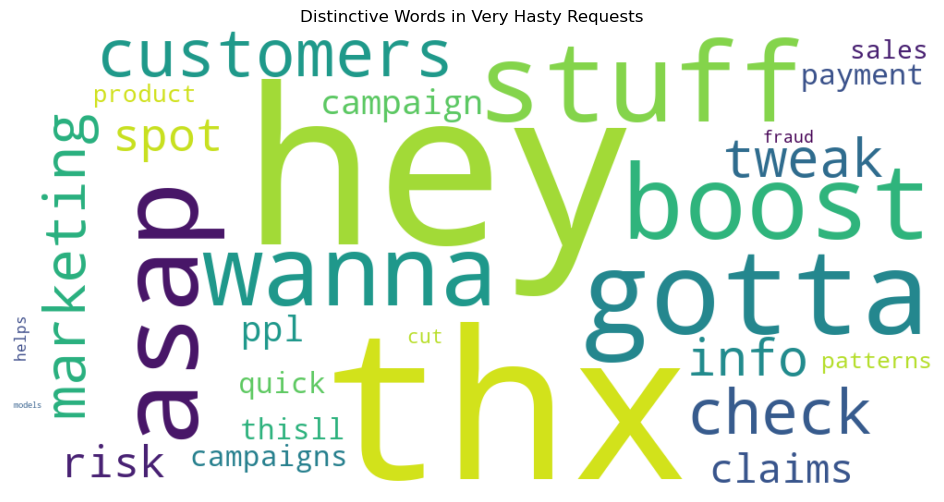

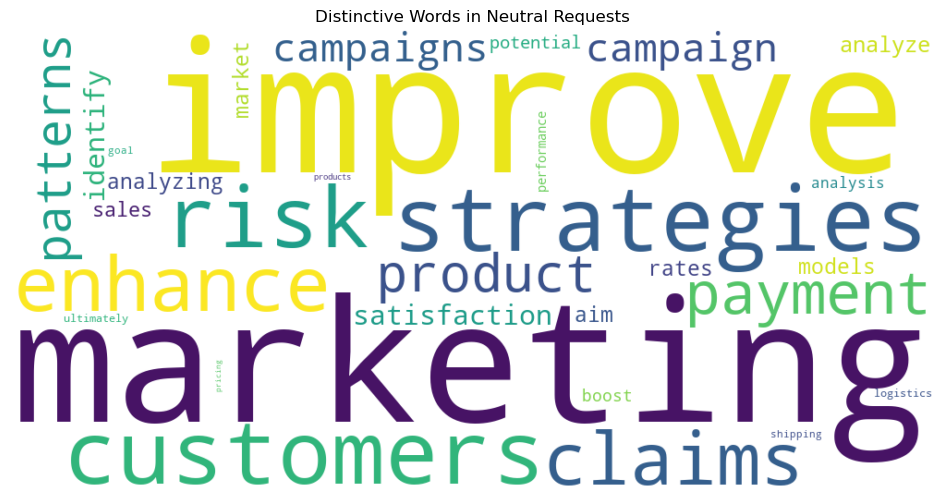

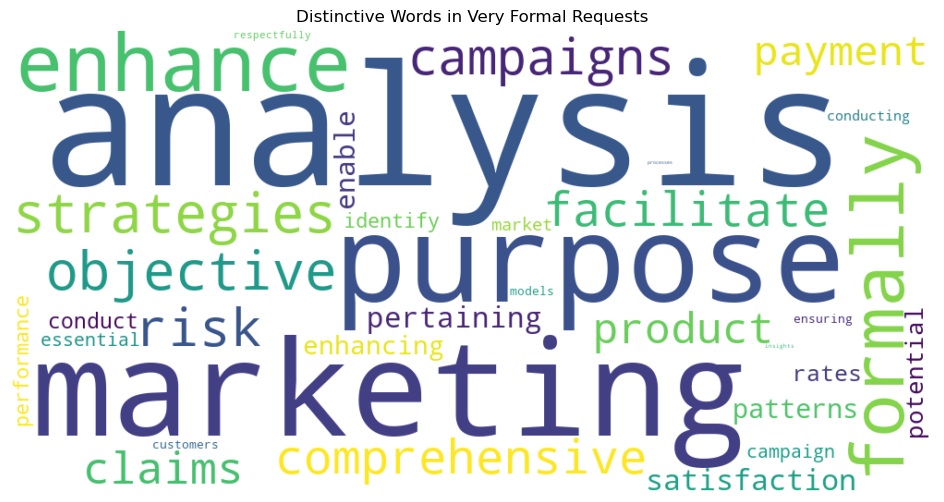

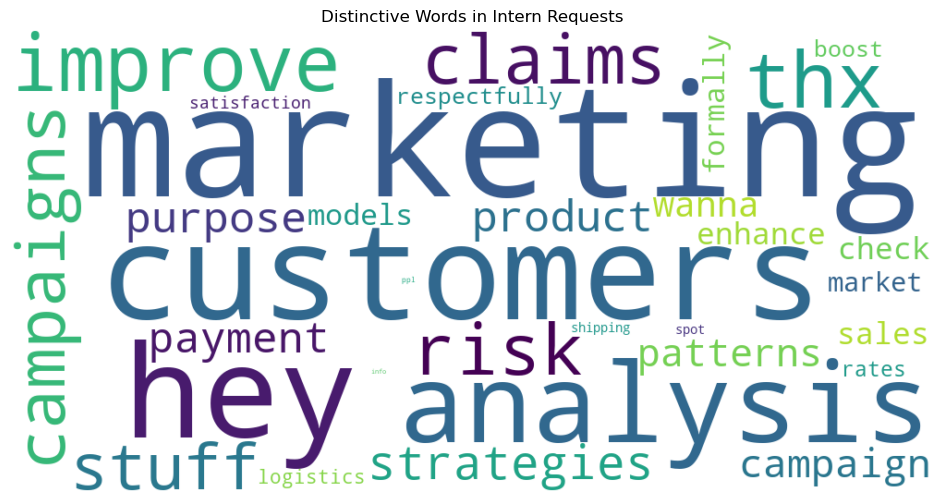

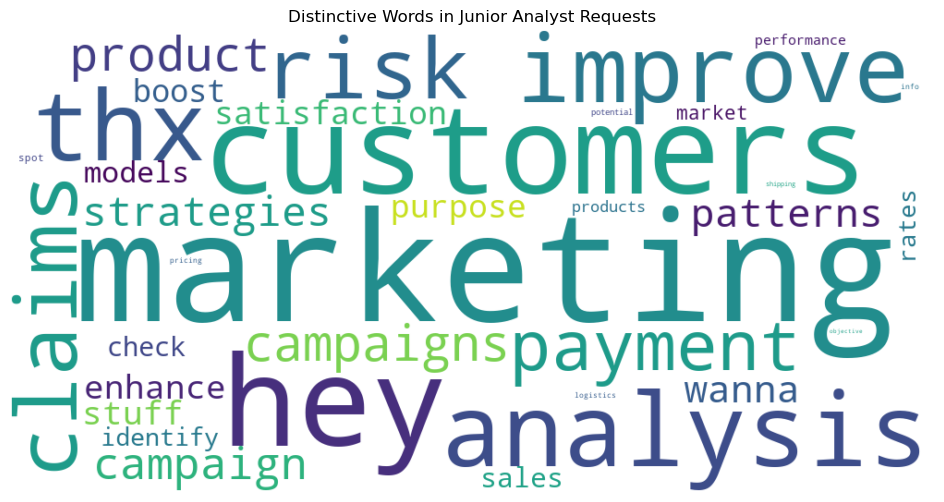

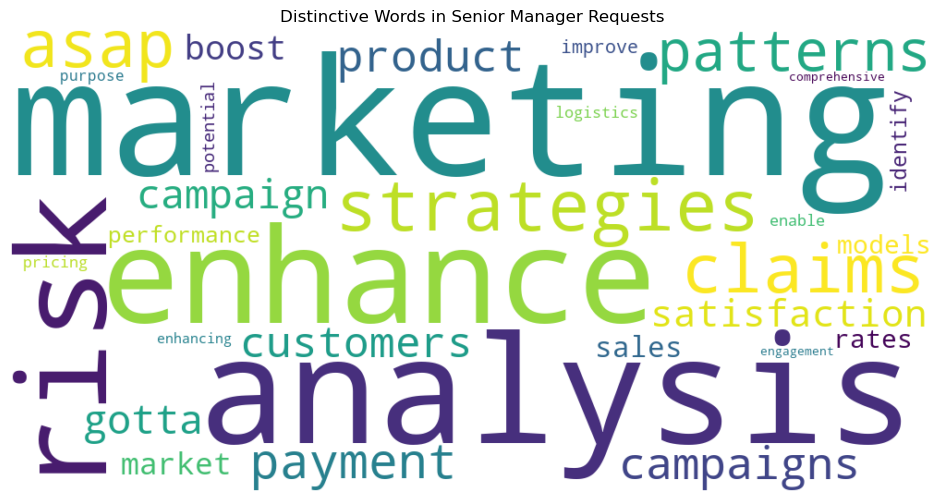

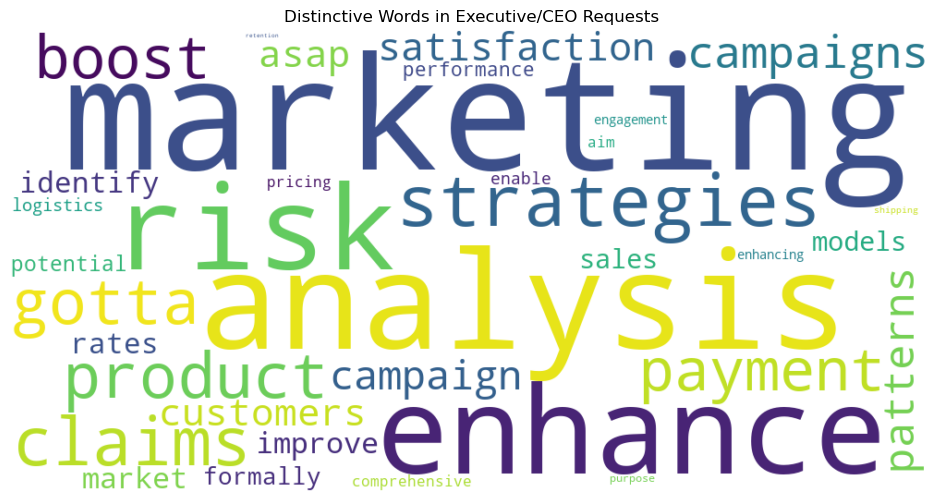

In [20]:
#plotting the wordcloud for the hastiness 

from wordcloud import WordCloud
import matplotlib.pyplot as plt

def plot_zscore_wordcloud(results_df, title):
    cloud_words = results_df[results_df["Z Score"] > 0].copy()

    frequencies = dict(zip(cloud_words["Word"],cloud_words["Z Score"]))

    wordcloud = WordCloud(
        width=1000,
        height=500,
        background_color="white"
    ).generate_from_frequencies(frequencies)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.show()

plot_zscore_wordcloud(very_hasty_results,"Distinctive Words in Very Hasty Requests")

plot_zscore_wordcloud(neutral_results,"Distinctive Words in Neutral Requests")

plot_zscore_wordcloud(very_formal_results,"Distinctive Words in Very Formal Requests")


plot_zscore_wordcloud(intern_results,"Distinctive Words in Intern Requests")

plot_zscore_wordcloud(junior_analyst_results,"Distinctive Words in Junior Analyst Requests")

plot_zscore_wordcloud(senior_manager_results,"Distinctive Words in Senior Manager Requests")

plot_zscore_wordcloud(executive_results,"Distinctive Words in Executive/CEO Requests")

In [ ]:
#plotting the word count trends across the hastiness and seniority
def plot_word_count_trends(
    results_dict,
    category_order,
    top_n=5,
    title="Word Count Trends"
):

    #getting the union of the top words across all categories
    top_words = set()

    for category in category_order:
        top = (
            results_dict[category]
            .nlargest(top_n, "Count")["Word"]
        )

        top_words.update(top)

    plt.figure(figsize=(12, 6))

    for word in sorted(top_words):

        counts = []

        for category in category_order:

            category_df = results_dict[category]

            match = category_df.loc[
                category_df["Word"] == word,
                "Count"
            ]

            if len(match) > 0:
                counts.append(match.iloc[0])
            else:
                counts.append(0)

        plt.plot(
            category_order,
            counts,
            marker="o",
            linewidth=2,
            label=word
        )

    plt.xlabel("Category")
    plt.ylabel("Word Count")
    plt.title(title)
    plt.grid(alpha=0.3)
    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )
    plt.tight_layout()
    plt.show()

In [22]:
hastiness_results = {
    "Very Hasty": very_hasty_results,
    "Neutral": neutral_results,
    "Very Formal": very_formal_results
}

seniority_results = {
    "Intern": intern_results,
    "Junior Analyst": junior_analyst_results,
    "Senior Manager": senior_manager_results,
    "Executive/CEO": executive_results
}

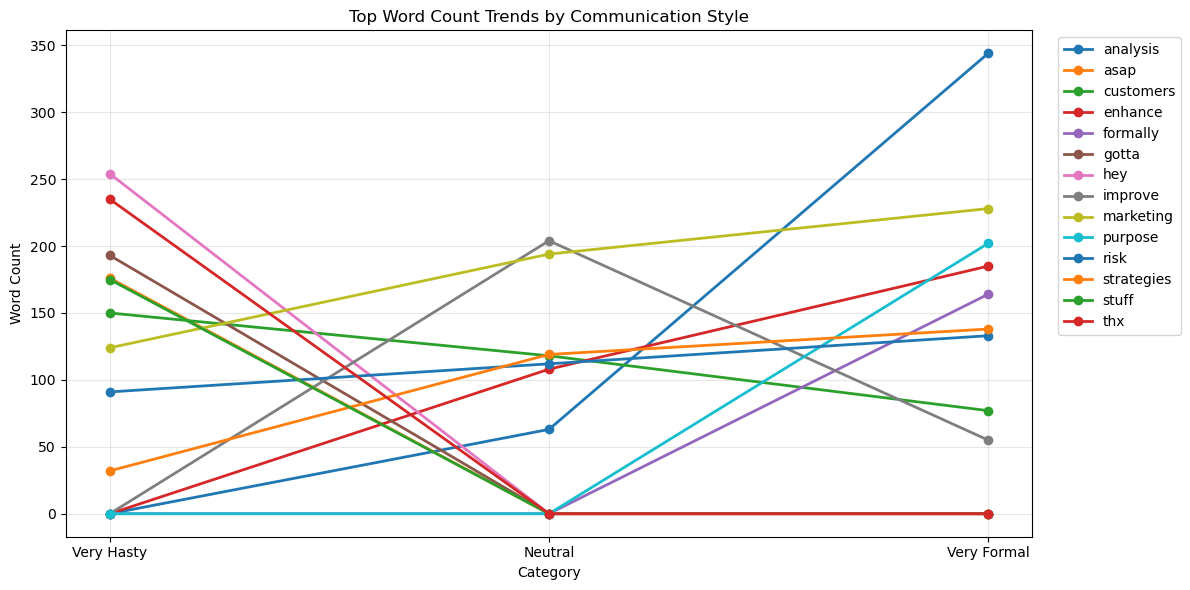

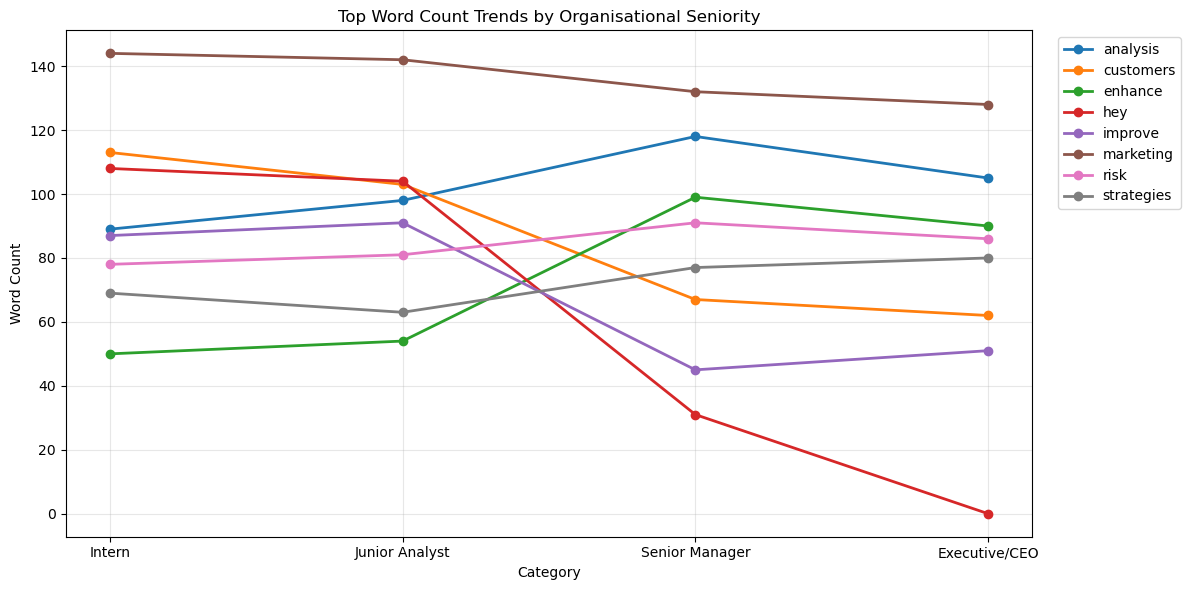

In [23]:
plot_word_count_trends(
    hastiness_results,
    ["Very Hasty", "Neutral", "Very Formal"],
    top_n=5,
    title="Top Word Count Trends by Communication Style"
)

plot_word_count_trends(
    seniority_results,
    [
        "Intern",
        "Junior Analyst",
        "Senior Manager",
        "Executive/CEO"
    ],
    top_n=5,
    title="Top Word Count Trends by Organisational Seniority"
)